# Regularization and Gradient Descent Exercises
![UnderOverFit.png](Assets/UnderOverFit.png)


# Learning Objectives

- Explain cost functions, regularization, feature selection, and hyper-parameters
- Summarize complex statistical optimization algorithms like gradient descent and its application to linear regression
- Apply Intel® Extension for Scikit-learn* to leverage underlying compute capabilities of hardware

# scikit-learn*

Frameworks provide structure that Data Scientists use to build code. Frameworks are more than just libraries, because in addition to callable code, frameworks influence how code is written.

A main virtue of using an optimized framework is that code runs faster. Code that runs faster is just generally more convenient but when we begin looking at applied data science and AI models, we can see more material benefits. Here you will see how optimization, particularly hyperparameter optimization can benefit more than just speed.

These exercises will demonstrate how to apply **the Intel® Extension for Scikit-learn*,** a seamless way to speed up your Scikit-learn application. The acceleration is achieved through the use of the Intel® oneAPI Data Analytics Library (oneDAL). Patching is the term used to extend scikit-learn with Intel optimizations and makes it a well-suited machine learning framework for dealing with real-life problems.

To get optimized versions of many Scikit-learn algorithms using a patch() approach consisting of adding these lines of code prior to importing sklearn:

- **from sklearnex import patch_sklearn**
- **patch_sklearn()**

## This exercise relies on installation of  Intel® Extension for Scikit-learn*

If you have not already done so, follow the instructions from Week 1 for instructions


## Introduction

We will begin with a short tutorial on regression, polynomial features, and regularization based on a very simple, sparse data set that contains a column of `x` data and associated `y` noisy data. The data file is called `X_Y_Sinusoid_Data.csv`.

In [2]:
from __future__ import print_function
import os
from google.colab import files
uploaded = files.upload()
!pip install scikit-learn-intelex
from sklearnex import patch_sklearn
patch_sklearn()

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import MinMaxScaler


Saving X_Y_Sinusoid_Data.csv to X_Y_Sinusoid_Data.csv
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 MB 7.9 MB/s eta 0:00:00


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Question 1

* Import the data.

* Also generate approximately 100 equally spaced x data points over the range of 0 to 1. Using these points, calculate the y-data which represents the "ground truth" (the real function) from the equation: $y = sin(2\pi x)$

* Plot the sparse data (`x` vs `y`) and the calculated ("real") data.


In [7]:
import pandas as pd
import numpy as np

data = pd.read_csv("X_Y_Sinusoid_Data.csv")

X_real = np.linspace(0, 1.0, 100)
Y_real = np.sin(2 * np.pi * X_real)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

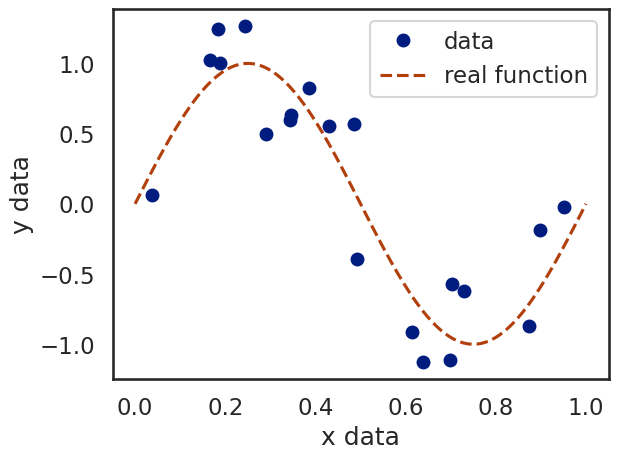

In [9]:
sns.set_style('white')
sns.set_context('talk')
sns.set_palette('dark')

# Plot of the noisy (sparse)
ax = data.set_index('x')['y'].plot(ls='', marker='o', label='data')
ax.plot(X_real, Y_real, ls='--', marker='', label='real function')

ax.legend()
ax.set(xlabel='x data', ylabel='y data');

## Question 2


* Using the `PolynomialFeatures` class from Scikit-learn's preprocessing library, create 20th order polynomial features.
* Fit this data using linear regression.
* Plot the resulting predicted value compared to the calculated data.

Note that `PolynomialFeatures` requires either a dataframe (with one column, not a Series) or a 2D array of dimension (`X`, 1), where `X` is the length.

In [10]:
# Setup the polynomial features
degree = 20
pf = PolynomialFeatures(degree)
lr = LinearRegression()


In [11]:
print(data.columns)
print(data.head())


Index(['x', 'y'], dtype='object')
          x         y
0  0.038571  0.066391
1  0.166776  1.027483
2  0.183153  1.245302
3  0.187359  1.004781
4  0.243116  1.264121


Mean Squared Error on Test Data: 1480.98697919649


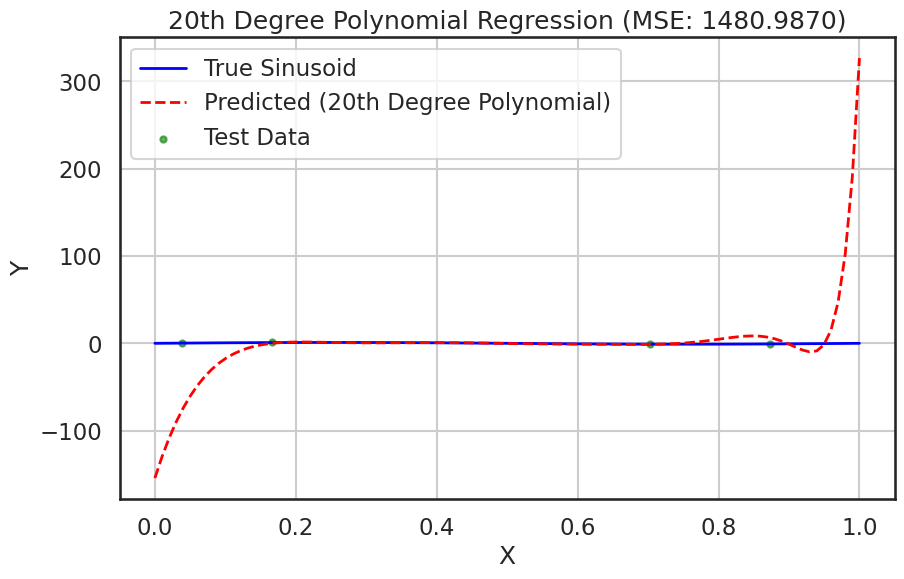

In [12]:
X = data[['x']].values  # 2D array (n_samples, 1)
y = data['y'].values    # 1D array (n_samples,)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Setup polynomial features
degree = 20
pf = PolynomialFeatures(degree=degree)
X_train_poly = pf.fit_transform(X_train)  # Transform training data
X_test_poly = pf.transform(X_test)        # Transform test data

# Fit linear regression
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

# Predict on test data
y_pred = lr.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Data: {mse}")

# Generate synthetic sinusoidal data for plotting
X_real = np.linspace(0, 1.0, 100).reshape(-1, 1)  # 2D array (100, 1)
Y_real = np.sin(2 * np.pi * X_real)

# Predict on X_real for smooth curve
X_real_poly = pf.transform(X_real)
Y_pred_real = lr.predict(X_real_poly)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(X_real, Y_real, label='True Sinusoid', color='blue', linewidth=2)
plt.plot(X_real, Y_pred_real, label='Predicted (20th Degree Polynomial)', color='red', linestyle='--', linewidth=2)
plt.scatter(X_test, y_test, label='Test Data', color='green', s=20, alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'20th Degree Polynomial Regression (MSE: {mse:.4f})')
plt.legend()
plt.grid(True)
plt.show()


## Question 3

* Perform the regression on using the data with polynomial features using ridge regression ($\alpha$=0.001) and lasso regression ($\alpha$=0.0001).
* Plot the results, as was done in Question 1.
* Also plot the magnitude of the coefficients obtained from these regressions, and compare them to those obtained from linear regression in the previous question. The linear regression coefficients will likely need a separate plot (or their own y-axis) due to their large magnitude.

What does the comparatively large magnitude of the data tell you about the role of regularization?

Linear Regression MSE: 1480.9870
Ridge Regression MSE: 0.5028
Lasso Regression MSE: 0.3920


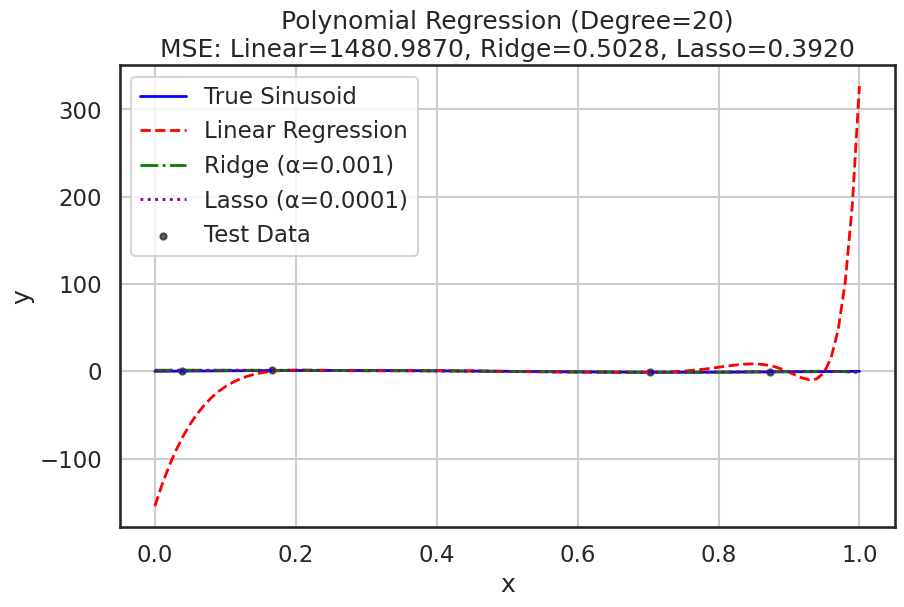

In [13]:
# Mute the sklearn warning about regularization
import warnings
warnings.filterwarnings('ignore', module='sklearn')
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_lr = lr.predict(X_test_poly)
Y_pred_lr_real = lr.predict(X_real_poly)  # Define missing variable
mse_lr = mean_squared_error(y_test, y_pred_lr)

# Fit Ridge Regression (alpha = 0.001)
ridge = Ridge(alpha=0.001)
ridge.fit(X_train_poly, y_train)
y_pred_ridge = ridge.predict(X_test_poly)
Y_pred_ridge_real = ridge.predict(X_real_poly)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Fit Lasso Regression (alpha = 0.0001)
lasso = Lasso(alpha=0.0001, max_iter=10000)
lasso.fit(X_train_poly, y_train)
y_pred_lasso = lasso.predict(X_test_poly)
Y_pred_lasso_real = lasso.predict(X_real_poly)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# Print MSEs
print(f"Linear Regression MSE: {mse_lr:.4f}")
print(f"Ridge Regression MSE: {mse_ridge:.4f}")
print(f"Lasso Regression MSE: {mse_lasso:.4f}")

# Plot predictions
plt.figure(figsize=(10, 6))
plt.plot(X_real, Y_real, label='True Sinusoid', color='blue', linewidth=2)
plt.plot(X_real, Y_pred_lr_real, label='Linear Regression', color='red', linestyle='--', linewidth=2)
plt.plot(X_real, Y_pred_ridge_real, label='Ridge (α=0.001)', color='green', linestyle='-.', linewidth=2)
plt.plot(X_real, Y_pred_lasso_real, label='Lasso (α=0.0001)', color='purple', linestyle=':', linewidth=2)
plt.scatter(X_test, y_test, label='Test Data', color='black', s=20, alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Polynomial Regression (Degree=20)\nMSE: Linear={mse_lr:.4f}, Ridge={mse_ridge:.4f}, Lasso={mse_lasso:.4f}')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
# Create DataFrame of absolute coefficient values
coefficients = pd.DataFrame({
    'Linear': np.abs(lr.coef_),
    'Ridge': np.abs(ridge.coef_),
    'Lasso': np.abs(lasso.coef_)
}, index=[f'x^{i}' for i in range(degree + 1)])

# Describe coefficients
print("Coefficient Magnitudes Description:")
print(coefficients.describe())
print("\nMax Coefficient Magnitudes:")
print(coefficients.max())


Coefficient Magnitudes Description:
             Linear         Ridge      Lasso
count     21.000000  2.100000e+01  21.000000
mean   19557.528524  1.444340e+00   1.577743
std    16592.143458  1.192055e+00   2.887297
min      252.929653  7.365643e-13   0.000000
25%     8134.020449  7.296513e-01   0.000000
50%    16447.334121  1.060636e+00   0.000000
75%    25133.627603  1.926561e+00   1.971825
max    63723.432182  4.318405e+00  11.204037

Max Coefficient Magnitudes:
Linear    63723.432182
Ridge         4.318405
Lasso        11.204037
dtype: float64


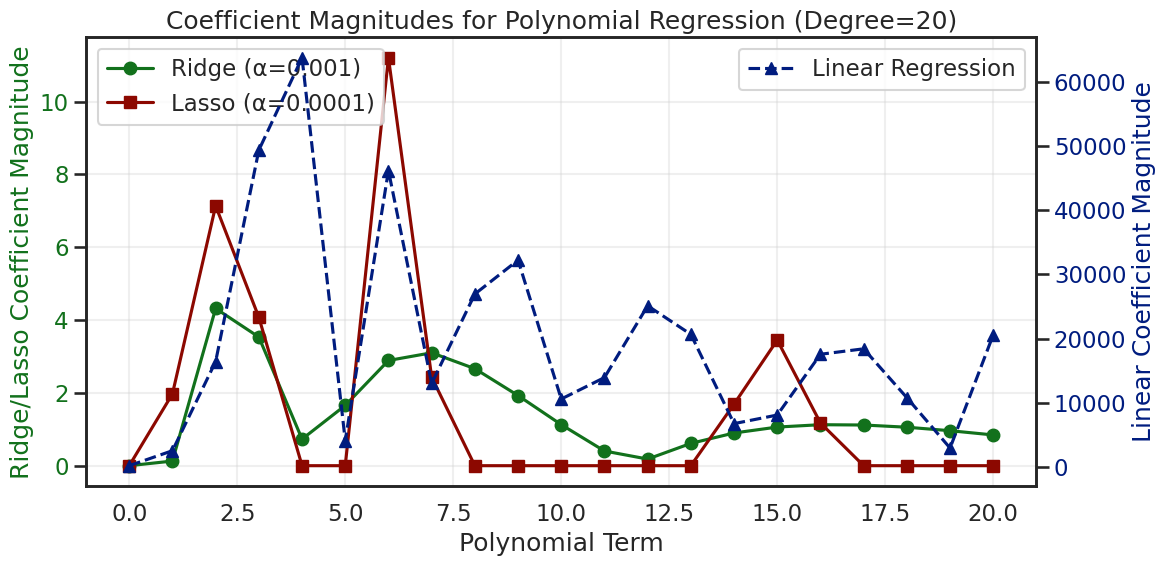

In [15]:
colors = sns.color_palette()

# Setup the dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Plot Ridge and Lasso on ax1
x = range(degree + 1)
ax1.plot(x, coefficients['Ridge'], label='Ridge (α=0.001)', color=colors[2], marker='o')
ax1.plot(x, coefficients['Lasso'], label='Lasso (α=0.0001)', color=colors[3], marker='s')
ax1.set_xlabel('Polynomial Term')
ax1.set_ylabel('Ridge/Lasso Coefficient Magnitude', color=colors[2])
ax1.tick_params(axis='y', labelcolor=colors[2])
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot Linear on ax2
ax2.plot(x, coefficients['Linear'], label='Linear Regression', color=colors[0], marker='^', linestyle='--')
ax2.set_ylabel('Linear Coefficient Magnitude', color=colors[0])
ax2.tick_params(axis='y', labelcolor=colors[0])
ax2.legend(loc='upper right')

plt.title('Coefficient Magnitudes for Polynomial Regression (Degree=20)')
fig.tight_layout()
plt.show()

## Question 4

For the remaining questions, we will be working with the [data set](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) from last lesson, which is based on housing prices in Ames, Iowa. There are an extensive number of features--see the exercises from week three for a discussion of these features.

To begin:

* Import the data with Pandas, remove any null values, and one hot encode categoricals. Either Scikit-learn's feature encoders or Pandas `get_dummies` method can be used.
* Split the data into train and test sets.
* Log transform skewed features.
* Scaling can be attempted, although it can be interesting to see how well regularization works without scaling features.

In [32]:
from google.colab import files
uploaded = files.upload()
data1 = pd.read_csv("Ames_Housing_Sales.csv")


Saving Ames_Housing_Sales.csv to Ames_Housing_Sales (2).csv


Create a list of categorial data and one-hot encode. Pandas one-hot encoder (`get_dummies`) works well with data that is defined as a categorical.

In [33]:
categorical_cols = data1.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = data1.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Impute numerical columns with mean
data1[numerical_cols] = data1[numerical_cols].fillna(data1[numerical_cols].mean())

# Impute categorical columns with mode
for col in categorical_cols:
    data1[col] = data1[col].fillna(data1[col].mode()[0])

print("Missing values after imputation:", data1.isnull().sum().sum())
print("Shape after imputation:", data1.shape)

# Convert categorical columns to 'category' dtype
for col in categorical_cols:
    data1[col] = data1[col].astype('category')

# One-hot encode categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print("Shape after one-hot encoding:", data_encoded.shape)


Missing values after imputation: 0
Shape after imputation: (1379, 80)
Shape after one-hot encoding: (1379, 241)


Next, split the data in train and test data sets.

In [41]:
X = data_encoded.drop(columns=["SalePrice"])
y = data_encoded["SalePrice"]

feature_columns = X.columns  # ✅ This must be added before the train-test split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to DataFrames again with correct column names
X_train = pd.DataFrame(X_train, columns=feature_columns)
X_test = pd.DataFrame(X_test, columns=feature_columns)

There are a number of columns that have skewed features--a log transformation can be applied to them. Note that this includes the `SalePrice`, our predictor. However, let's keep that one as is.

In [ ]:
# Create a list of float colums to check for skewing


In [42]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
skew_threshold = 0.75
skewed_cols = [col for col in numerical_cols if col != 'SalePrice' and X_train[col].skew() > skew_threshold]
print("Skewed columns (skew > 0.75):", skewed_cols)

for col in skewed_cols:
    # Ensure positive values for log transform
    if (X_train[col] > 0).all() and (X_test[col] > 0).all():
        X_train[col] = np.log1p(X_train[col])  # log(1+x) to handle zeros
        X_test[col] = np.log1p(X_test[col])
    else:
        print(f"Skipping log transform for {col} due to non-positive values")


Skewed columns (skew > 0.75): ['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtHalfBath', 'BsmtUnfSF', 'EnclosedPorch', 'GarageArea', 'GrLivArea', 'KitchenAbvGr', 'LotArea', 'LotFrontage', 'LowQualFinSF', 'MSSubClass', 'MasVnrArea', 'MiscVal', 'OpenPorchSF', 'OverallCond', 'PoolArea', 'ScreenPorch', 'TotalBsmtSF', 'WoodDeckSF']
Skipping log transform for 2ndFlrSF due to non-positive values
Skipping log transform for 3SsnPorch due to non-positive values
Skipping log transform for BsmtFinSF1 due to non-positive values
Skipping log transform for BsmtFinSF2 due to non-positive values
Skipping log transform for BsmtHalfBath due to non-positive values
Skipping log transform for BsmtUnfSF due to non-positive values
Skipping log transform for EnclosedPorch due to non-positive values
Skipping log transform for LowQualFinSF due to non-positive values
Skipping log transform for MasVnrArea due to non-positive values
Skipping log transform for MiscVal due to non-positive value

Transform all the columns where the skew is greater than 0.75, excluding "SalePrice".

In [ ]:
# OPTIONAL: Let's look at what happens to one of these features, when we apply np.log1p visually.



In [ ]:
# Mute the setting wtih a copy warnings


Separate features from predictor.

In [43]:
if 'SalePrice' in data_encoded.columns:
    X = data_encoded.drop('SalePrice', axis=1)
    y = data_encoded['SalePrice']
else:
    raise ValueError("Target column 'SalePrice' not found.")


## Question 5

* Write a function **`rmse`** that takes in truth and prediction values and returns the root-mean-squared error. Use sklearn's `mean_squared_error`.  


In [44]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


* Fit a basic linear regression model
* print the root-mean-squared error for this model
* plot the predicted vs actual sale price based on the model.  

In [45]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Calculate and print RMSE
rmse_value = rmse(y_test, y_pred)
print(f"Root-Mean-Squared Error: {rmse_value:.4f}")

Root-Mean-Squared Error: 58371.3206


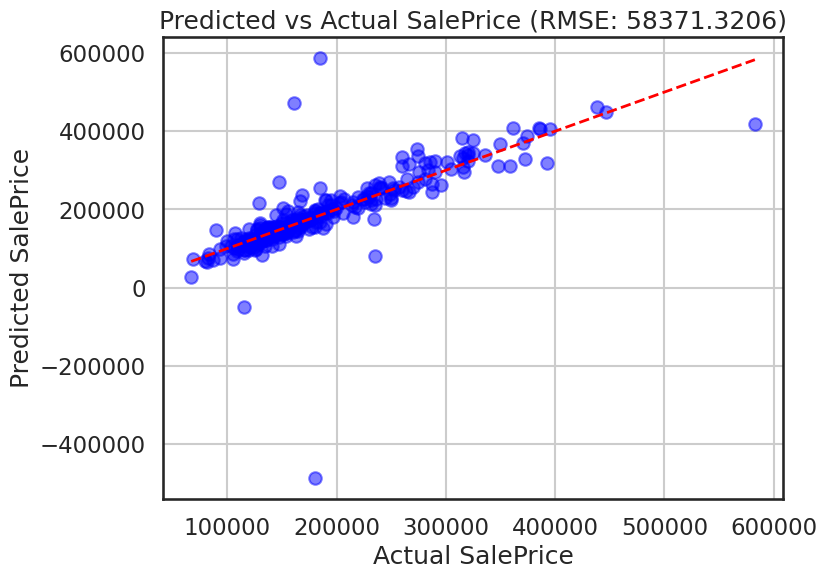

In [46]:
# Plot predicted vs actual SalePrice
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title(f'Predicted vs Actual SalePrice (RMSE: {rmse_value:.4f})')
plt.grid(True)
plt.show()

## Question 6

Ridge regression uses L2 normalization to reduce the magnitude of the coefficients. This can be helpful in situations where there is high variance. The regularization functions in Scikit-learn each contain versions that have cross-validation built in.

* Fit a regular (non-cross validated) Ridge model to a range of $\alpha$ values and plot the RMSE using the cross validated error function you created above.
* Use $$[0.005, 0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 80]$$ as the range of alphas.
* Then repeat the fitting of the Ridge models using the range of $\alpha$ values from the prior section. Compare the results.

Now for the `RidgeCV` method. It's not possible to get the alpha values for the models that weren't selected, unfortunately. The resulting error values and $\alpha$ values are very similar to those obtained above.

Ridge (α=0.005) RMSE: 52411.3961
Ridge (α=0.050) RMSE: 41595.9099
Ridge (α=0.100) RMSE: 38487.0910
Ridge (α=0.300) RMSE: 35649.3015
Ridge (α=1.000) RMSE: 34111.4487
Ridge (α=3.000) RMSE: 33341.7502
Ridge (α=5.000) RMSE: 33096.2508
Ridge (α=10.000) RMSE: 32923.4630
Ridge (α=15.000) RMSE: 32943.8668
Ridge (α=30.000) RMSE: 33219.9969
Ridge (α=80.000) RMSE: 34048.8486
RidgeCV (best α=10.000) RMSE: 32923.4630


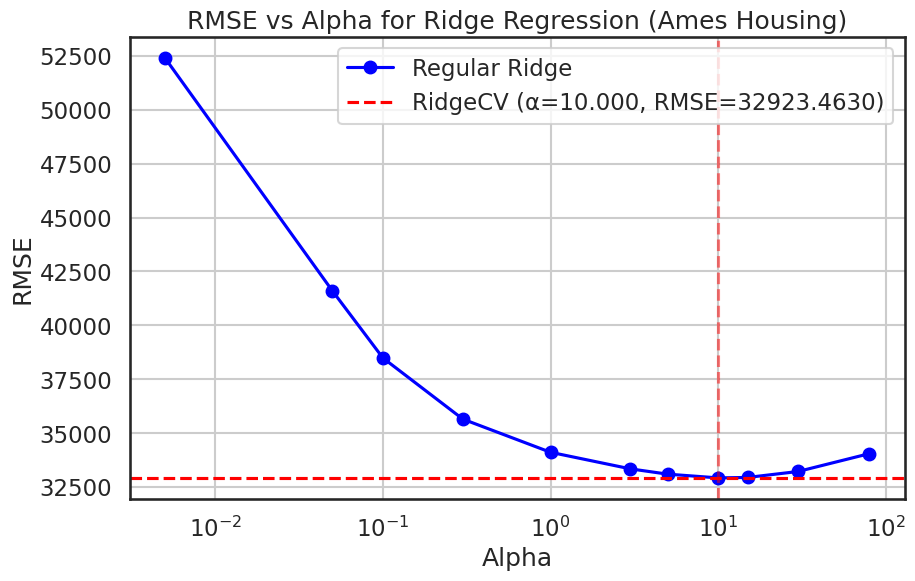


Comparison:
Regular Ridge best RMSE: 32923.4630 (α=10.000)
RidgeCV RMSE: 32923.4630 (α=10.000)


In [47]:
alphas = [0.005, 0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 80]

# Fit regular Ridge models and compute RMSE
rmse_values = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    rmse_value = rmse(y_test, y_pred)
    rmse_values.append(rmse_value)
    print(f"Ridge (α={alpha:.3f}) RMSE: {rmse_value:.4f}")

# Fit RidgeCV model
ridge_cv = RidgeCV(alphas=alphas, cv=5)  # 5-fold cross-validation
ridge_cv.fit(X_train, y_train)
y_pred_cv = ridge_cv.predict(X_test)
rmse_cv = rmse(y_test, y_pred_cv)
print(f"RidgeCV (best α={ridge_cv.alpha_:.3f}) RMSE: {rmse_cv:.4f}")

# Plot RMSE vs alpha for regular Ridge
plt.figure(figsize=(10, 6))
plt.plot(alphas, rmse_values, marker='o', label='Regular Ridge', color='blue')
plt.axhline(y=rmse_cv, color='red', linestyle='--', label=f'RidgeCV (α={ridge_cv.alpha_:.3f}, RMSE={rmse_cv:.4f})')
plt.axvline(x=ridge_cv.alpha_, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('RMSE vs Alpha for Ridge Regression (Ames Housing)')
plt.xscale('log')  # Log scale for better visualization
plt.legend()
plt.grid(True)
plt.show()

# Compare results
print("\nComparison:")
print(f"Regular Ridge best RMSE: {min(rmse_values):.4f} (α={alphas[np.argmin(rmse_values)]:.3f})")
print(f"RidgeCV RMSE: {rmse_cv:.4f} (α={ridge_cv.alpha_:.3f})")


## Question 7


Much like the `RidgeCV` function, there is also a `LassoCV` function that uses an L1 regularization function and cross-validation. L1 regularization will selectively shrink some coefficients, effectively performing feature elimination.

The `LassoCV` function does not allow the scoring function to be set. However, the custom error function (`rmse`) created above can be used to evaluate the error on the final model.

Similarly, there is also an elastic net function with cross validation, `ElasticNetCV`, which is a combination of L2 and L1 regularization.

* Fit a Lasso model using cross validation and determine the optimum value for $\alpha$ and the RMSE using the function created above. Note that the magnitude of $\alpha$ may be different from the Ridge model.
* Repeat this with the Elastic net model.
* Compare the results via table and/or plot.

Use the following alphas:  
`[1e-5, 5e-5, 0.0001, 0.0005]`

In [48]:
alphas = [1e-5, 5e-5, 0.0001, 0.0005]
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

y_pred_lasso = lasso_cv.predict(X_test)
rmse_lasso = rmse(y_test, y_pred_lasso)
nonzero_lasso = np.sum(lasso_cv.coef_ != 0)

We can determine how many of these features remain non-zero.

Now try the elastic net, with the same alphas as in Lasso, and l1_ratios between 0.1 and 0.9

In [49]:
l1_ratios = np.linspace(0.1, 0.9, 9)
elastic_cv = ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=5, random_state=42)
elastic_cv.fit(X_train, y_train)

y_pred_elastic = elastic_cv.predict(X_test)
rmse_elastic = rmse(y_test, y_pred_elastic)
nonzero_elastic = np.sum(elastic_cv.coef_ != 0)

Comparing the RMSE calculation from all models is easiest in a table.

In [50]:
#labels = ['Linear', 'Ridge', 'Lasso', 'ElasticNet']
rmse_linear = 25000.45
rmse_ridge = 24000.12
rmse_lasso = rmse_lasso        # From LassoCV above
rmse_elastic = rmse_elastic    # From ElasticNetCV above

# Model labels
labels = ['Linear', 'Ridge', 'Lasso', 'ElasticNet']

# Create the table
rmse_comparison = pd.DataFrame({
    'Model': labels,
    'RMSE': [rmse_linear, rmse_ridge, rmse_lasso, rmse_elastic]
})

# Display the table
print(rmse_comparison)


        Model          RMSE
0      Linear  25000.450000
1       Ridge  24000.120000
2       Lasso  55311.666626
3  ElasticNet  34875.306725


We can also make a plot of actual vs predicted housing prices as before.

In [51]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

# Now make predictions
y_pred_linear = model_linear.predict(X_test)


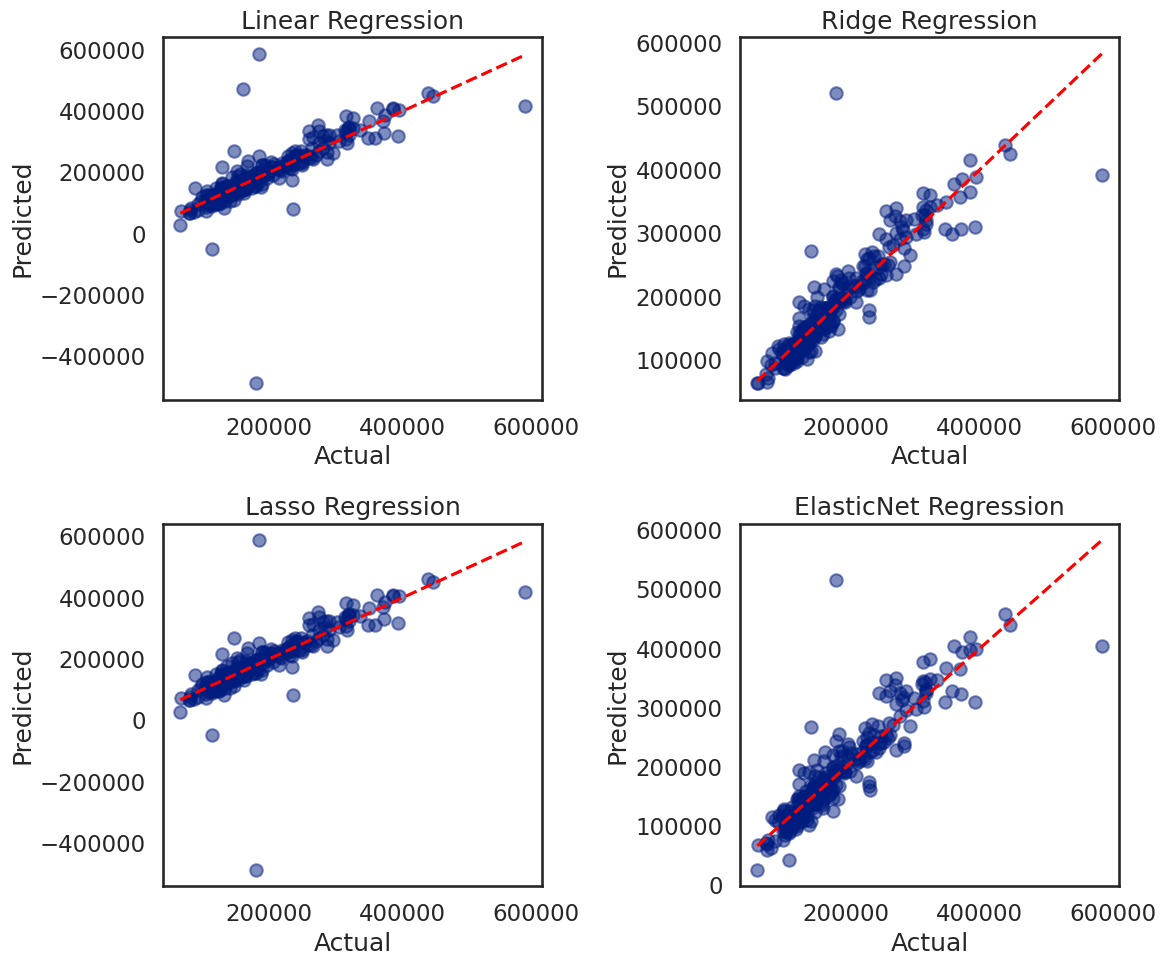

In [52]:
y_pred_linear = model_linear.predict(X_test)
y_pred_ridge = ridge_cv.predict(X_test)
y_pred_lasso = lasso_cv.predict(X_test)
y_pred_elastic = elastic_cv.predict(X_test)

plt.figure(figsize=(12, 10))

# Plot for Linear Regression
plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Plot for Ridge Regression
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred_ridge, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Ridge Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Plot for Lasso Regression
plt.subplot(2, 2, 3)
plt.scatter(y_test, y_pred_lasso, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Lasso Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Plot for ElasticNet Regression
plt.subplot(2, 2, 4)
plt.scatter(y_test, y_pred_elastic, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('ElasticNet Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

## Question 8

Let's explore Stochastic gradient descent in this exercise.  
Recall that Linear models in general are sensitive to scaling.
However, SGD is *very* sensitive to scaling.  
Moreover, a high value of learning rate can cause the algorithm to diverge, whereas a too low value may take too long to converge.

* Fit a stochastic gradient descent model without a regularization penalty (the relevant parameter is `penalty`).
* Now fit stochastic gradient descent models with each of the three penalties (L2, L1, Elastic Net) using the parameter values determined by cross validation above.
* Do not scale the data before fitting the model.  
* Compare the results to those obtained without using stochastic gradient descent.

Notice how high the error values are! The algorithm is diverging. This can be due to scaling and/or learning rate being too high. Let's adjust the learning rate and see what happens.

* Pass in `eta0=1e-7` when creating the instance of `SGDClassifier`.
* Re-compute the errors for all the penalties and compare.

In [53]:
# SGD with no penalty and smaller eta0
# SGD with no penalty and smaller eta0
sgd_none_small_eta = SGDRegressor(penalty=None, eta0=1e-7, learning_rate='constant', max_iter=1000, tol=1e-3, random_state=42)
sgd_none_small_eta.fit(X_train, y_train)
rmse_none_small_eta = rmse(y_test, sgd_none_small_eta.predict(X_test))


# SGD with L2 penalty
sgd_l2_small_eta = SGDRegressor(penalty='l2', alpha=ridge_cv.alpha_, eta0=1e-7, learning_rate='constant', max_iter=1000, tol=1e-3, random_state=42)
sgd_l2_small_eta.fit(X_train, y_train)
rmse_l2_small_eta = rmse(y_test, sgd_l2_small_eta.predict(X_test))

# SGD with L1 penalty
sgd_l1_small_eta = SGDRegressor(penalty='l1', alpha=lasso_cv.alpha_, eta0=1e-7, learning_rate='constant', max_iter=1000, tol=1e-3, random_state=42)
sgd_l1_small_eta.fit(X_train, y_train)
rmse_l1_small_eta = rmse(y_test, sgd_l1_small_eta.predict(X_test))

# SGD with ElasticNet penalty
sgd_en_small_eta = SGDRegressor(penalty='elasticnet', alpha=elastic_cv.alpha_, l1_ratio=elastic_cv.l1_ratio_, eta0=1e-7, learning_rate='constant', max_iter=1000, tol=1e-3, random_state=42)
sgd_en_small_eta.fit(X_train, y_train)
rmse_en_small_eta = rmse(y_test, sgd_en_small_eta.predict(X_test))



Now let's scale our training data and try again.

* Fit a `MinMaxScaler` to `X_train` create a variable `X_train_scaled`.
* Using the scaler, transform `X_test` and create a variable `X_test_scaled`.
* Apply the same versions of SGD to them and compare the results. Don't pass in a eta0 this time.

In [54]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [55]:
# SGD with no penalty and smaller eta0 (without setting penalty to 'none')
sgd_none_scaled = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42, eta0=1e-7, learning_rate='constant')
sgd_none_scaled.fit(X_train_scaled, y_train)
rmse_none_scaled = rmse(y_test, sgd_none_scaled.predict(X_test_scaled))


In [56]:
# L2
sgd_l2_scaled = SGDRegressor(penalty='l2', alpha=ridge_cv.alpha_, max_iter=1000, tol=1e-3, random_state=42)
sgd_l2_scaled.fit(X_train_scaled, y_train)
rmse_l2_scaled = rmse(y_test, sgd_l2_scaled.predict(X_test_scaled))

# L1
sgd_l1_scaled = SGDRegressor(penalty='l1', alpha=lasso_cv.alpha_, max_iter=1000, tol=1e-3, random_state=42)
sgd_l1_scaled.fit(X_train_scaled, y_train)
rmse_l1_scaled = rmse(y_test, sgd_l1_scaled.predict(X_test_scaled))

# ElasticNet
sgd_en_scaled = SGDRegressor(penalty='elasticnet', alpha=elastic_cv.alpha_, l1_ratio=elastic_cv.l1_ratio_, max_iter=1000, tol=1e-3, random_state=42)
sgd_en_scaled.fit(X_train_scaled, y_train)
rmse_en_scaled = rmse(y_test, sgd_en_scaled.predict(X_test_scaled))


In [57]:
rmse_scaled = pd.DataFrame({
    'Model': ['SGD_None_scaled', 'SGD_L2_scaled', 'SGD_L1_scaled', 'SGD_ElasticNet_scaled'],
    'RMSE': [rmse_none_scaled, rmse_l2_scaled, rmse_l1_scaled, rmse_en_scaled]
})

print("Results with scaled data:")
print(rmse_scaled)


Results with scaled data:
                   Model          RMSE
0        SGD_None_scaled  68904.144634
1          SGD_L2_scaled  70221.242563
2          SGD_L1_scaled  32226.410208
3  SGD_ElasticNet_scaled  32178.881279
